In [2]:
import  os 
import random 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import mne 
from mne.datasets import eegbci 
from mne.io import read_raw_edf,concatenate_raws
from scipy.signal import butter, lfilter, welch 
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
import tensorflow as tf 
from tensorflow.keras import layers, Model, callbacks, regularizers

print(tf.__version__ + "is the tf version")

2.16.2is the tf version


In [3]:
SEED= 42 
os.environ['PYTHONSHEED'] = str(SEED)
random.seed(SEED) 
np.random.seed(SEED) 
tf.random.set_seed(SEED) 
print("Random seed=",SEED)

Random seed= 42


In [4]:
N= 5000 
gaussian_noise = np.random.normal(loc=0.0,scale=1.0 ,size=N)
print("Mean=",np.mean(gaussian_noise))
print("Standard Deviation=",np.std(gaussian_noise))
print("Variance=",np.var(gaussian_noise))

Mean= 0.005601930087572765
Standard Deviation= 0.996380175855159
Variance= 0.9927734548371576


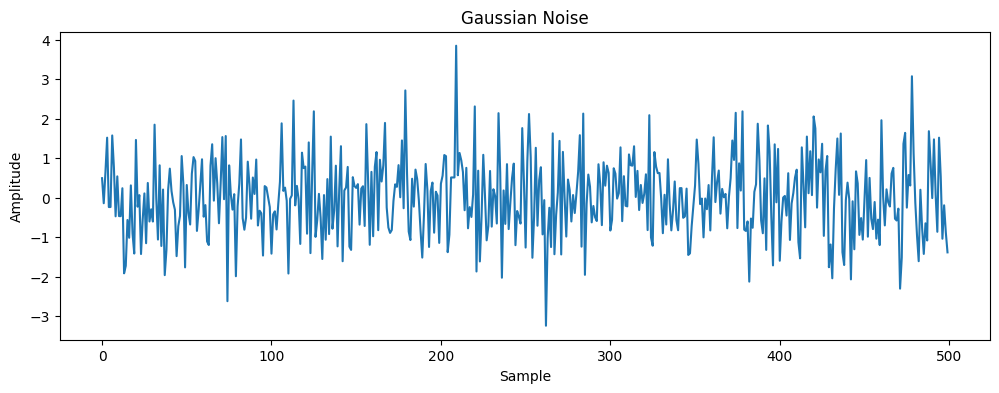

In [5]:
plt.figure(figsize=(12,4))
plt.plot(gaussian_noise[:500])
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Gaussian Noise")
plt.show()

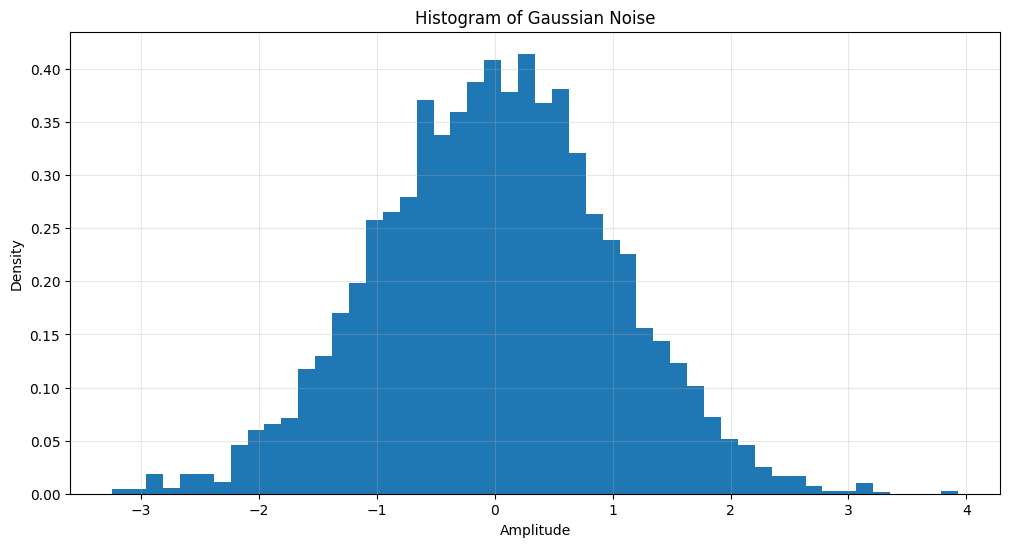

In [6]:
plt.figure(figsize=(12,6))
plt.hist(gaussian_noise,bins=50,density=True)
plt.xlabel("Amplitude")
plt.ylabel("Density")
plt.title("Histogram of Gaussian Noise")
plt.grid(alpha=0.3)
plt.show()

In [7]:
noise_power = np.mean(gaussian_noise**2)
noise_variance = np.var(gaussian_noise)
print("Noise Power=",noise_power)
print("Noise Variance=",noise_variance)

Noise Power= 0.9928048364578637
Noise Variance= 0.9927734548371576


In [8]:
power_linear= 10 
power_db= 10 * np.log10(power_linear)
print(power_db)
power_back=10**(power_db/10)
print(power_back)

10.0
10.0


In [9]:
signal_power= 1.0 
noise_power=0.1 
snr_linear=signal_power/noise_power
snr_db=10 * np.log10(snr_linear)
print("SNR in dB=",snr_db)
print("snr db=",snr_linear)

SNR in dB= 10.0
snr db= 10.0


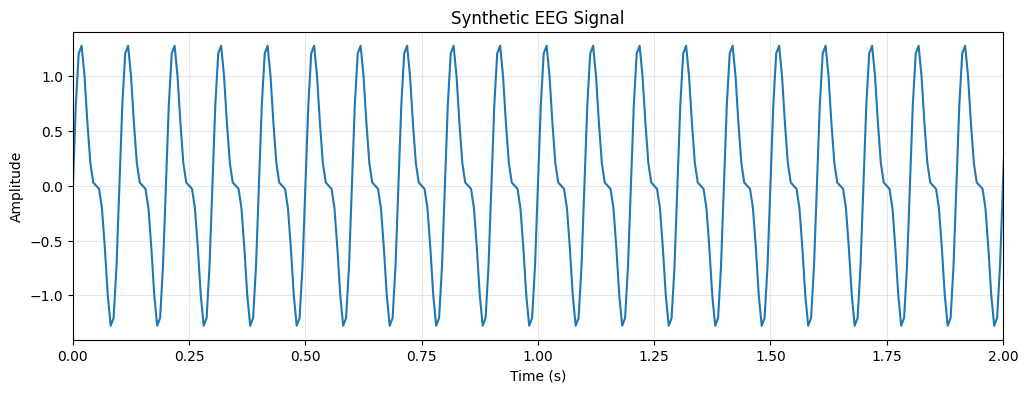

In [10]:
fs= 160 
duration = 5 
t = np.arange(0,duration,1/fs)
signal_10hz=np.sin(2*np.pi*10*t)
signal_20hz=np.sin(2*np.pi*20*t)*0.5
synthetic_eeg=signal_10hz+signal_20hz
plt.figure(figsize=(12,4))
plt.plot(t,synthetic_eeg)
plt.xlim(0,2)
plt.title("Synthetic EEG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.show()

In [11]:
def add_awgn(signal,snr_db,seed=None):
       rng= np.random.default_rng(seed)
       signal_power= np.mean(signal**2)
       snr_linear=10**(snr_db/10)
       noise_power=(signal_power/snr_linear)
       noise_std =np.sqrt(noise_power)
       noise= rng.normal(loc=0.0,scale=noise_std, size = signal.shape)
       noisy_signal= signal + noise
       return noisy_signal

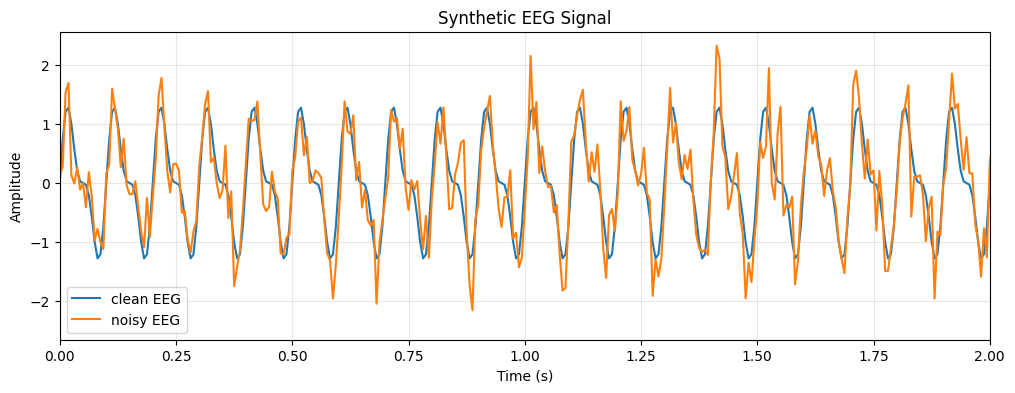

In [12]:
synthetic_noisy=add_awgn(synthetic_eeg,snr_db=5,seed=SEED)
plt.figure(figsize=(12,4))
plt.plot(t,synthetic_eeg,label='clean EEG')
plt.plot(t,synthetic_noisy,label='noisy EEG')
plt.xlim(0,2)
plt.title("Synthetic EEG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

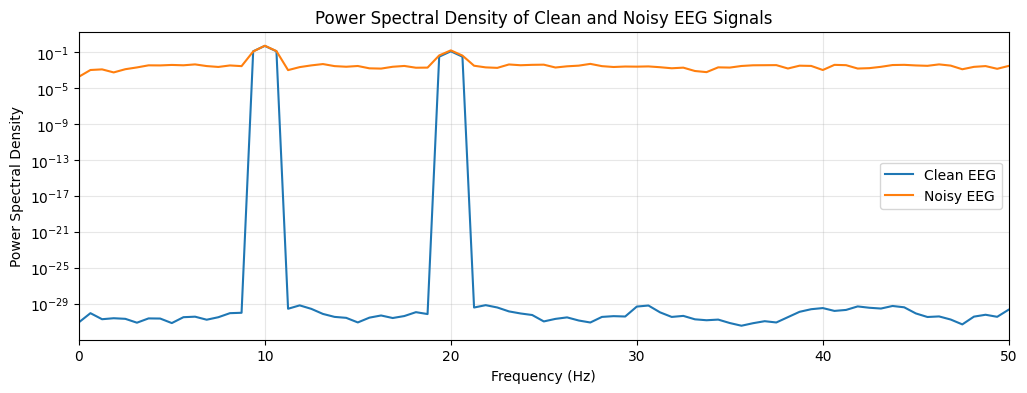

In [13]:
frequency, psd_clean = welch(synthetic_eeg, fs=fs, nperseg=256)
_, psd_noisy = welch(synthetic_noisy, fs=fs, nperseg=256)

plt.figure(figsize=(12, 4))
plt.semilogy(frequency, psd_clean, label='Clean EEG')
plt.semilogy(frequency, psd_noisy, label='Noisy EEG')
plt.xlim(0, 50)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectral Density of Clean and Noisy EEG Signals')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [14]:
TRAIN_SUBJECTS = [1, 2, 3, 4, 5, 6]
TRAINING_SUBJECTS = TRAIN_SUBJECTS
VAL_SUBJECTS = [7]
TEST_SUBJECTS = [8]

print('Train Subjects =', TRAIN_SUBJECTS)
print('Val Subjects   =', VAL_SUBJECTS)
print('Test Subjects  =', TEST_SUBJECTS)


Train Subjects = [1, 2, 3, 4, 5, 6]
Val Subjects   = [7]
Test Subjects  = [8]


In [15]:
all_subjects = TRAIN_SUBJECTS + VAL_SUBJECTS + TEST_SUBJECTS
runs = [6, 10, 14]  # Motor imagery runs: hands (T1) vs feet (T2)

X_by_subject = {}
y_by_subject = {}

for subject in all_subjects:
    raw_fnames = eegbci.load_data(subject, runs, verbose=False)
    raws = [read_raw_edf(f, preload=True, verbose=False) for f in raw_fnames]
    raw = concatenate_raws(raws, verbose=False)
    eegbci.standardize(raw)
    raw.filter(7.0, 30.0, fir_design='firwin', verbose=False)
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    epochs = mne.Epochs(raw, events, dict(T1=2, T2=3), tmin=1.0, tmax=3.0, baseline=None, preload=True, verbose=False)
    X_by_subject[subject] = epochs.get_data()
    y_by_subject[subject] = epochs.events[:, -1] - 2
    print(f'Subject {subject}: X = {X_by_subject[subject].shape}, y = {y_by_subject[subject].shape}')


Subject 1: X = (45, 64, 321), y = (45,)


Subject 2: X = (45, 64, 321), y = (45,)


Subject 3: X = (45, 64, 321), y = (45,)


Subject 4: X = (45, 64, 321), y = (45,)


Subject 5: X = (45, 64, 321), y = (45,)


Subject 6: X = (45, 64, 321), y = (45,)


Subject 7: X = (45, 64, 321), y = (45,)


Subject 8: X = (45, 64, 321), y = (45,)


In [16]:
RUNS = [6, 10, 14]
TMIN = 0.0
TMAX = 4.0


def load_subject_epochs(subject, runs=RUNS, tmin=TMIN, tmax=TMAX):
    file_paths = eegbci.load_data(subject, runs)
    raw_list = [
        read_raw_edf(file_path, preload=True, verbose=False)
        for file_path in file_paths
    ]

    raw = concatenate_raws(raw_list)
    eegbci.standardize(raw)
    raw.set_montage('standard_1005', on_missing='ignore', verbose=False)
    raw.filter(7.0, 30.0, fir_design='firwin', skip_by_annotation='edge', verbose=False)

    event_id = {
        'T1': 1,
        'T2': 2
    }
    events, _ = mne.events_from_annotations(raw, event_id=event_id, verbose=False)
    picks = mne.pick_types(raw.info, eeg=True, exclude='bads')

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        picks=picks,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data().astype(np.float32)
    y = (epochs.events[:, -1] - 1).astype(np.int64)

    return X, y


ALL_SUBJECTS = sorted(
    set(TRAIN_SUBJECTS + VAL_SUBJECTS + TEST_SUBJECTS)
)

X_by_subject = {}
y_by_subject = {}

for subject in ALL_SUBJECTS:
    X_by_subject[subject], y_by_subject[subject] = load_subject_epochs(subject)
    print(
        f'Subject {subject}:',
        X_by_subject[subject].shape,
        y_by_subject[subject].shape
    )


Subject 1: (45, 64, 641) (45,)
Subject 2: (45, 64, 641) (45,)
Subject 3: (45, 64, 641) (45,)
Subject 4: (45, 64, 641) (45,)
Subject 5: (45, 64, 641) (45,)
Subject 6: (45, 64, 641) (45,)
Subject 7: (45, 64, 641) (45,)
Subject 8: (45, 64, 641) (45,)


In [17]:
def merge_subjects(
    subject_list
):

    X = np.concatenate(
        [
            X_by_subject[s]
            for s in subject_list
        ],
        axis=0
    )

    y = np.concatenate(
        [
            y_by_subject[s]
            for s in subject_list
        ],
        axis=0
    )

    return X, y

In [18]:
X_train, y_train = merge_subjects(
    TRAIN_SUBJECTS
)

X_val, y_val = merge_subjects(
    VAL_SUBJECTS
)

X_test, y_test = merge_subjects(
    TEST_SUBJECTS
)

print(
    "X Train:",
    X_train.shape
)

print(
    "X Validation:",
    X_val.shape
)

print(
    "X Test:",
    X_test.shape
)

X Train: (270, 64, 641)
X Validation: (45, 64, 641)
X Test: (45, 64, 641)


In [19]:
train_mean= np.mean(X_train,axis=(0,1),keepdims=True)
train_std=np.std(X_train,axis=(0,1),keepdims=True)
train_std=train_std+1e-8 
X_train_norm=(X_train-train_mean)/train_std
X_val_norm=(X_val-train_mean)/train_std
X_test_norm=(X_test-train_mean)
print("Normalized train shape:",X_train_norm.shape)

Normalized train shape: (270, 64, 641)


In [20]:
train_mean = np.mean(
    X_train,
    axis=(0, 1),
    keepdims=True
)

train_std = np.std(
    X_train,
    axis=(0, 1),
    keepdims=True
)

train_std = train_std + 1e-8

X_train_norm = (
    X_train - train_mean
) / train_std

X_val_norm = (
    X_val - train_mean
) / train_std

X_test_norm = (
    X_test - train_mean
) / train_std

print(
    "Normalized train shape:",
    X_train_norm.shape
)

Normalized train shape: (270, 64, 641)


In [21]:
def add_awn_batch(X,snr_db,seed=None):
       rng = np.random.default_rng(seed)
       X=X.astype(np.float32)
       signal_power=np.mean(X**2,axis=(1,2),keepdims=True)
       snr_linear=10**(snr_db/10)
       disered_noise_power=(signal_power/snr_linear)
       noise=rng.standard_normal(X.shape)*np.sqrt(disered_noise_power)
       return X+noise

In [22]:
X_train_noisy=add_awn_batch(X_train_norm,snr_db=10,seed=42)
print("Noisy train shape:",X_train_noisy.shape)

Noisy train shape: (270, 64, 641)


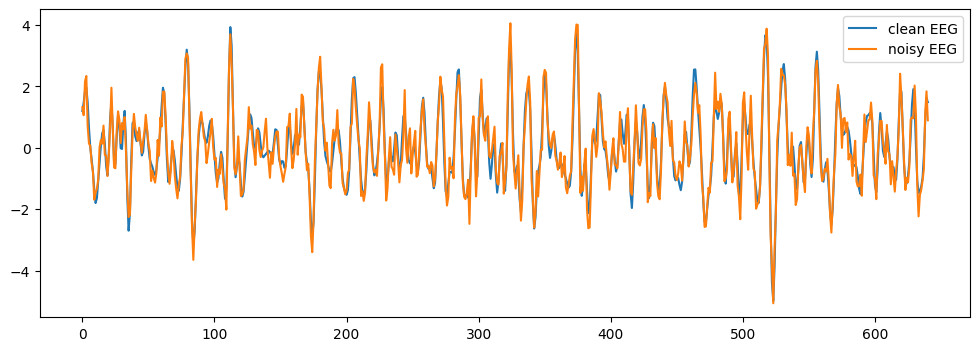

In [23]:
sample_index = 0
channel_index = 0 
plt.figure(figsize=(12,4))
plt.plot(X_train_norm[sample_index,channel_index,:],label='clean EEG')
plt.plot(X_train_noisy[sample_index,channel_index,:],label='noisy EEG')
plt.legend()
plt.show()

encoder 

In [24]:
def build_encoder(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Permute (channels, time) -> (time, channels) so Conv1D operates over time
    x = layers.Permute((2, 1))(inputs)
    x = layers.GaussianNoise(0.05)(x)

    # Block 1: Temporal Conv (kernel_size=15 captures ~100ms at 160Hz)
    x = layers.Conv1D(
        filters=16,
        kernel_size=15,
        padding="same",
        kernel_regularizer=regularizers.l2(1e-3)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling1D(pool_size=4)(x)
    x = layers.Dropout(0.3)(x)

    # Block 2: Higher-level temporal features
    x = layers.Conv1D(
        filters=32,
        kernel_size=7,
        padding="same",
        kernel_regularizer=regularizers.l2(1e-3)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling1D(pool_size=4)(x)
    x = layers.Dropout(0.3)(x)

    encoder = Model(inputs, x, name="EEG_Encoder")
    return encoder

In [25]:
INPUT_SHAPE = (X_train_norm.shape[1], X_train_norm.shape[2])
encoder = build_encoder(INPUT_SHAPE)
encoder.summary()

Model: "EEG_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 641)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 641, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 641, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 641, 16)        │        15,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 641, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 641, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 160, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 160, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 160, 32)        │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 160, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 40, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 32)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,184 (74.94 KB)

 Trainable params: 19,088 (74.56 KB)

 Non-trainable params: 96 (384.00 B)

In [26]:
def build_eeg_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    encoder = build_encoder(input_shape=input_shape)
    x = encoder(inputs)
    
    # BiLSTM with recurrent dropout & L2 regularization
    x = layers.Bidirectional(
        layers.LSTM(
            16,
            return_sequences=False,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=regularizers.l2(1e-3)
        )
    )(x)
    
    # Regularized Dense classification head
    x = layers.Dense(32, activation='elu', kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(2, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='EEG_Classifier')
    return model

In [27]:
model = build_eeg_model(INPUT_SHAPE)
model.summary()

Model: "EEG_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 641)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ EEG_Encoder (Functional)        │ (None, 40, 32)         │        19,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,578 (103.82 KB)

 Trainable params: 26,482 (103.45 KB)

 Non-trainable params: 96 (384.00 B)

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

In [29]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [30]:
history = model.fit(
    X_train_noisy,
    y_train,
    validation_data=(
        X_val_norm,
        y_val
    ),
    epochs=60,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.5074 - loss: 0.9486 - val_accuracy: 0.5111 - val_loss: 0.9432 - learning_rate: 5.0000e-04
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5185 - loss: 0.8931 - val_accuracy: 0.5111 - val_loss: 0.9259 - learning_rate: 5.0000e-04
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5111 - loss: 0.9032 - val_accuracy: 0.4667 - val_loss: 0.9181 - learning_rate: 5.0000e-04
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5000 - loss: 0.8842 - val_accuracy: 0.4889 - val_loss: 0.9092 - learning_rate: 5.0000e-04
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.5296 - loss: 0.8854 - val_accuracy: 0.4889 - val_loss: 0.9092 - learning_rate: 5.0000e-04
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5556 - loss: 0.8655 - val_accuracy: 0.4889 - val_loss: 0.9069 - learning_rate: 5.0000e-04
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.5074 - loss: 0.884